
# 11. 실제 한국어 글 + 출처마다 다른 신뢰도: 조합으로만 풀리는 문제

**세계**: 실제 KLUE 기사로 만든 질문 40개가 한 세션이다. 출처는 4명이고, 각자 숨은 정확도(0.95 / 0.75 / 0.5 / 0.2)가 있다.
- 정직하게 전할 때는 원래 기사를 준다.
- 거짓말할 때는 기사 속 정답을 같은 기사의 그럴듯한 다른 표현으로 덮은 오보를 준다(예: "페이펄 → 트위터").
- 읽기 전문가는 오보를 알아채지 못한다(구별 지표 AUC 0.58).
- 오보는 늘 같은 가짜 답이라서 거짓 출처들끼리 서로 동의한다(루머).

| 방식 | 읽기 점수를 쓰나 | 신뢰를 배우나 |
|---|---|---|
| 다수결 | 아니오 | 아니오 |
| 읽기 확신 거르기 | 예 | 아니오 |
| 수학 공식 | 아니오 | 예 (피드백) |
| **학습형 신뢰 부품** (2,386개) | **예** | **예** |


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V
V.setup()
SEEDS = (42, 43, 44)
runs = {s: json.loads((S.RESULTS / f"world-v6_trust_seed-{s}.json").read_text(encoding="utf-8")) for s in SEEDS}
for s in SEEDS:
    t = runs[s]["test"]; print(s, {k: t[k] for k in ("majority", "reading_confidence", "formula_learner", "learned", "knows_accuracies")}, runs[s]["learned_minus_confidence"])


42 {'majority': 0.0, 'reading_confidence': 0.1322, 'formula_learner': 0.1087, 'learned': 0.1752, 'knows_accuracies': 0.1867} {'mean': 0.043, 'bootstrap_95': [0.0223, 0.0635]}
43 {'majority': 0.0, 'reading_confidence': 0.152, 'formula_learner': 0.1527, 'learned': 0.211, 'knows_accuracies': 0.2328} {'mean': 0.059, 'bootstrap_95': [0.038, 0.08]}
44 {'majority': 0.0, 'reading_confidence': 0.146, 'formula_learner': 0.1255, 'learned': 0.1945, 'knows_accuracies': 0.225} {'mean': 0.0485, 'bootstrap_95': [0.0278, 0.069]}



## 1. 점수: 두 신호를 함께 쓰는 조합만 둘 다 이긴다

점선은 출처 정확도를 처음부터 아는 베이즈 기준선이다(읽기 점수는 안 씀).


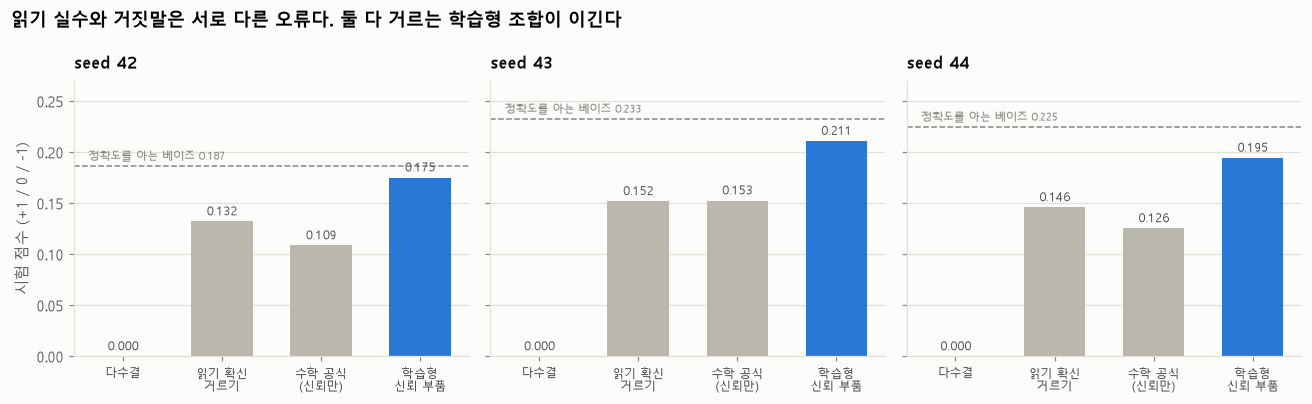

In [2]:

items = [("다수결", "majority", V.NEUTRAL), ("읽기 확신\n거르기", "reading_confidence", V.NEUTRAL),
         ("수학 공식\n(신뢰만)", "formula_learner", V.NEUTRAL), ("학습형\n신뢰 부품", "learned", V.BLUE)]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharey=True)
for ax, s in zip(axes, SEEDS):
    t = runs[s]["test"]
    for i, (label, key, color) in enumerate(items):
        ax.bar(i, t[key], width=0.62, color=color)
        ax.text(i, t[key] + 0.006, f"{t[key]:.3f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    ax.axhline(t["knows_accuracies"], color=V.MUTED, ls="--", lw=1)
    ax.text(-0.35, t["knows_accuracies"] + 0.006, f"정확도를 아는 베이즈 {t['knows_accuracies']:.3f}", fontsize=7.5, color=V.MUTED)
    ax.set_xticks(range(4), [x[0] for x in items], fontsize=8)
    ax.set_ylim(0, 0.27)
    ax.grid(axis="x", visible=False)
    ax.set_title(f"seed {s}", fontsize=11, pad=8)
axes[0].set_ylabel("시험 점수 (+1 / 0 / -1)")
fig.suptitle("읽기 실수와 거짓말은 서로 다른 오류다. 둘 다 거르는 학습형 조합이 이긴다", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()



## 2. 세션 안에서 누구를 믿을지 배운다

세션 안 문제 구간별 학습형 신뢰 부품의 점수다. 회색 점선은 신뢰를 배우지 않는 읽기 확신 거르기다. 구간마다 질문이 달라서 질문 난이도가 섞인다. 그래서 곡선이 매끄럽지 않다.


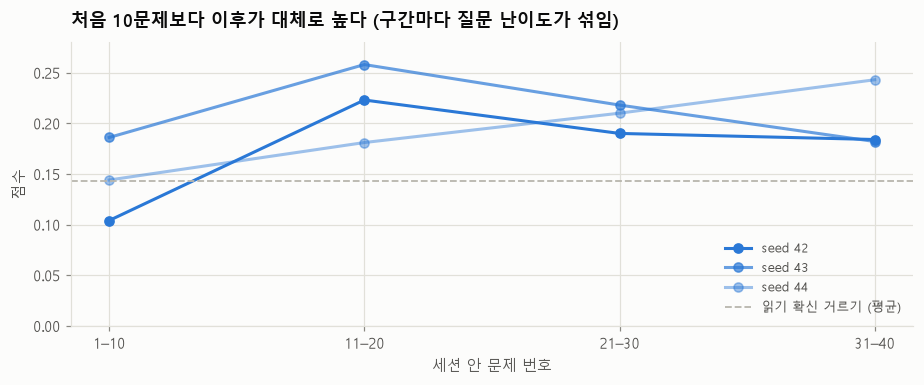

In [3]:

fig, ax = plt.subplots(figsize=(8.5, 3.6))
x = ["1–10", "11–20", "21–30", "31–40"]
for i, s in enumerate(SEEDS):
    ax.plot(x, runs[s]["test"]["learned_by_10"], "-o", color=V.BLUE, alpha=[1, 0.7, 0.45][i], label=f"seed {s}")
ax.axhline(np.mean([runs[s]["test"]["reading_confidence"] for s in SEEDS]), color=V.NEUTRAL, ls="--", lw=1.2, label="읽기 확신 거르기 (평균)")
ax.set_xlabel("세션 안 문제 번호")
ax.set_ylabel("점수")
ax.set_ylim(0, 0.28)
ax.legend(fontsize=8.5, frameon=False, loc="lower right")
ax.set_title("처음 10문제보다 이후가 대체로 높다 (구간마다 질문 난이도가 섞임)", pad=10)
fig.tight_layout()
plt.show()



## 3. 정리

- **졸업.** 학습형 신뢰 부품이 가장 강한 "신뢰 없는" 방식(읽기 확신 거르기)보다 +0.043 / +0.059 / +0.049 높다. 짝 부트스트랩 95% 구간은 모두 0보다 크다. 신뢰만 쓰는 수학 공식보다는 평균 +0.064 높다.
- 출처 정확도를 처음부터 아는 베이즈와의 차이는 0.012–0.030이다.
- 세션 안 중복 질문을 없애고 다시 돌린 결과다(처음 실행: +0.034 / +0.058 / +0.060, 역시 졸업).
- **다수결은 루머 때문에 손해**다. 거짓 출처들이 같은 가짜 답에 동의한다.
- **의미**: 읽기 전문가(5단계)는 오보를 알아채지 못하고, 신뢰 공식은 읽기 실수를 못 거른다. **실제 한국어 글에서 전문가 하나로는 원리적으로 못 푸는 문제를, 얼린 전문가 + 작은 학습형 부품(2,386개)의 조합으로 풀었다.**
- 한계: 글은 실제지만 거짓말은 합성이다(기사 속 정답을 덮음). 가짜 답의 품질이 고르지 않다. 답 없는 질문은 뺐다. 남은 오류의 큰 부분은 정직한 출처의 기사를 읽기 전문가가 잘못 읽는 경우다.
